In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [23]:
data_dir = './data'
data_output_dir = './data/output'

In [3]:
data_casy = pd.read_csv(f'{data_dir}/Casy.csv', index_col=False)
data_casy.head()



,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts
0,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212
1,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292
2,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407
3,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570
4,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625


In [4]:
data_casy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   sample_type         54 non-null     object 
 1   channel             54 non-null     int64  
 2   replicate           54 non-null     int64  
 3   mean_diameter       54 non-null     float64
 4   peak_diameter       54 non-null     float64
 5   sample_dilution     54 non-null     int64  
 6   measurement_name    54 non-null     int64  
 7   sample_volume       54 non-null     int64  
 8   casyton_volume      54 non-null     int64  
 9   measurement_volume  54 non-null     int64  
 10  counts              54 non-null     int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 4.8+ KB


In [5]:
data_casy['channel'].unique()

array([4, 5, 7, 3, 8, 1])

In [6]:
### Data structure:
# sample_type: to identify whether it is MC, BBB, or ABB
# channel: one culture. Within each channel, 
#  - array([4, 5, 7, 3, 8, 1])
#  - there are 3 sample types (MC, BBB, ABB) 
#  - 3 replicates of each sample type. So there are 9 samples in total for each channel.
# measurement_name: unique to each sample_type and measurement, but NOT unique to replicates of the same sample_type and measurement
# sample_type: to identify whether it is MC, BBB, or ABB
# replicate: for the 3 runs of the same sample
#
# MC = Multi-Cultivator sample, not used for ploidy determination
# BBB = before bead-beating
# ABB = after bead-beating

In [7]:
# sample_id format: ch{channel}_{sample_type}_{measurement_name}
# sample_rep_id format: {sample_id}_r{replicate}
data_casy['sample_id'] = (
    'ch' + data_casy['channel'].astype(str)
    + '_' + data_casy['sample_type'].astype(str)
    + '_' + data_casy['measurement_name'].astype(str)
)
data_casy['sample_rep_id'] = (
    data_casy['sample_id']
    + '_r' + data_casy['replicate'].astype(str)
)

cols = data_casy.columns.tolist()
cols = ['sample_id', 'sample_rep_id'] + [col for col in cols if col not in ['sample_id', 'sample_rep_id']]
data_casy = data_casy[cols]
data_casy.head()

,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625


In [8]:
### Casy Counter
# Protocol
# 1. Dilute sample of interest (measurement range)
# 2. Pipette 10 μL dilution into CASY-vial with 10 mL of CASY-ton buffer
# 3. Insert CASY-vial into CASY-counter
# 4. Measure:
#     - CASY-counter will perform 3 measurements of each sample
#     - Each measurement will take 200 μL from CASY-vial
#     - The machine will report for each measurement:
#         - Total number of counts
#         - Peak diameter
#         - Average diameter
#
# So, this means that:
# - 10 μL of diluted sample
# - into 10000 μL of CASY-ton buffer
#
# example calculation:
# measurement_volume = 200μL
# counts = 2212
# sample_volume = 10 μL  e.
# casyton_volume = 10000 μL
# sample_dilution = 2    e.g. sample is diluted to 1:2 with casyton volumee
#
# Formula:
# cells / μL = (counts / measurement_volume) * ((sample_volume + casyton_volume) / sample_volume) * sample_dilution
#
# Example:
# cells / μL = (2212 / 200) * ((10 + 10000) / 10) * 2
# cells / μL = 11.06 * 1001 * 2
# cells / μL = 22142.12
#
# cells / mL = cells / μL * 1000
# cells / mL = 22142.12 * 1000
# cells / mL = 22142120


data_casy['counts_per_ul_casy_vial'] = data_casy['counts'] / data_casy["measurement_volume"] 

data_casy['counts_per_ul_diluted_sample'] = data_casy['counts_per_ul_casy_vial'] * ((data_casy['sample_volume'] + data_casy['casyton_volume']) / data_casy['sample_volume'])

data_casy['counts_per_ul_original_sample'] = data_casy['counts_per_ul_diluted_sample'] * data_casy['sample_dilution']

data_casy['counts_per_ml_original_sample'] = data_casy['counts_per_ul_original_sample'] * 1000

data_casy.head()


,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,sample_dilution,measurement_name,sample_volume,casyton_volume,measurement_volume,counts,counts_per_ul_casy_vial,counts_per_ul_diluted_sample,counts_per_ul_original_sample,counts_per_ml_original_sample
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2,13,10,10000,200,2212,11.060,11071.060,22142.12,22142120.0
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2,13,10,10000,200,2292,11.460,11471.460,22942.92,22942920.0
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2,13,10,10000,200,2407,12.035,12047.035,24094.07,24094070.0
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,2,6,10,10000,200,570,2.850,2852.850,5705.70,5705700.0
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,2,6,10,10000,200,625,3.125,3128.125,6256.25,6256250.0


In [9]:
data_casy_counts = data_casy.drop(columns=['sample_dilution', 'measurement_name', 'sample_volume', 'casyton_volume', 'measurement_volume'])
data_casy_counts.head()

,sample_id,sample_rep_id,sample_type,channel,replicate,mean_diameter,peak_diameter,counts,counts_per_ul_casy_vial,counts_per_ul_diluted_sample,counts_per_ul_original_sample,counts_per_ml_original_sample
0,ch4_ABB_13,ch4_ABB_13_r1,ABB,4,1,2.0477,1.519,2212,11.060,11071.060,22142.12,22142120.0
1,ch4_ABB_13,ch4_ABB_13_r2,ABB,4,2,2.0490,1.460,2292,11.460,11471.460,22942.92,22942920.0
2,ch4_ABB_13,ch4_ABB_13_r3,ABB,4,3,2.0726,1.616,2407,12.035,12047.035,24094.07,24094070.0
3,ch5_ABB_6,ch5_ABB_6_r1,ABB,5,1,2.1146,1.479,570,2.850,2852.850,5705.70,5705700.0
4,ch5_ABB_6,ch5_ABB_6_r2,ABB,5,2,2.0694,1.577,625,3.125,3128.125,6256.25,6256250.0


In [10]:
# average across replicate measurements for each sample_id
# reduce data to one value per channel + sample_type by avg of replicates

data_casy_avg = (
    data_casy
    .groupby(['channel', 'sample_type'], as_index=False)
    .agg(
        mean_cells_per_ml=('counts_per_ml_original_sample', 'mean'),
        sd_cells_per_ml=('counts_per_ml_original_sample', 'std'),
        n_replicates=('counts_per_ml_original_sample', 'size')
    )
)

data_casy_avg = data_casy_avg.sort_values(by='channel').reset_index(drop=True)
data_casy_avg['sample_id'] = 'ch' + data_casy_avg['channel'].astype(str) + '_' + data_casy_avg['sample_type']
data_casy_avg.head()

,channel,sample_type,mean_cells_per_ml,sd_cells_per_ml,n_replicates,sample_id
0,1,ABB,6.639633e+07,7.159775e+05,3,ch1_ABB
1,1,BBB,2.303134e+08,8.148831e+06,3,ch1_BBB
2,1,MC,2.258256e+07,4.057756e+05,3,ch1_MC
3,3,ABB,1.313646e+07,1.332997e+05,3,ch3_ABB
4,3,BBB,2.586751e+08,6.632018e+06,3,ch3_BBB


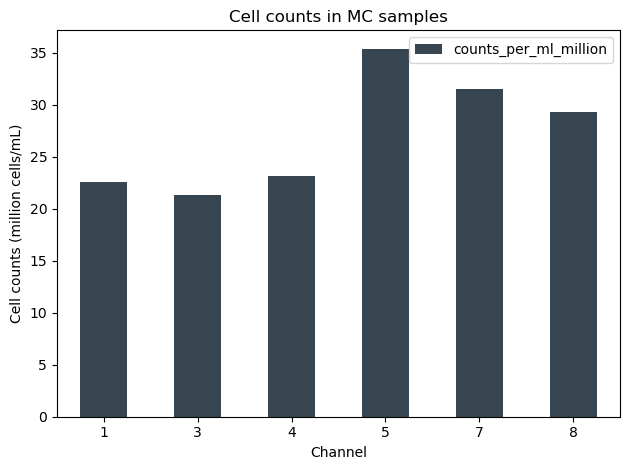

In [11]:
# Cell counts in MC samples (millions of cells per mL)
mc_counts = data_casy_avg[
    data_casy_avg['sample_type'].str.lower() == 'mc'
].copy()
mc_counts['counts_per_ml_million'] = mc_counts['mean_cells_per_ml'] / 1_000_000
mc_counts = mc_counts.sort_values('channel')

mc_counts.plot(x='channel', y='counts_per_ml_million', kind='bar', color='#36454F')
plt.ylabel('Cell counts (million cells/mL)')
plt.xlabel('Channel')
plt.title('Cell counts in MC samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

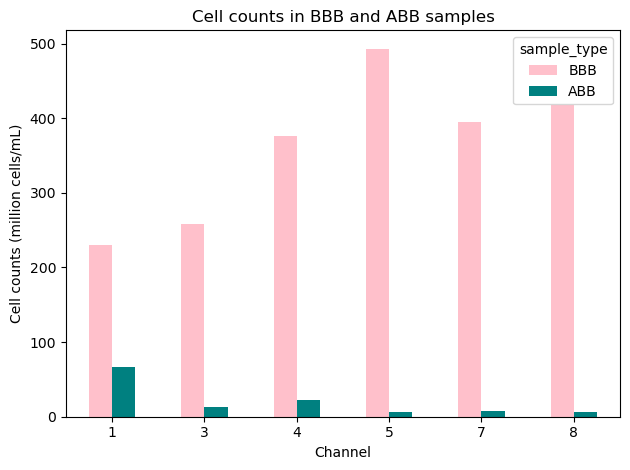

In [12]:
# cell counts in BBB and ABB samples (millions of cells / mL)
# grouped by channel and sample type (BBB vs ABB)
bbb_abb_counts = data_casy_avg[
    data_casy_avg['sample_type'].str.lower().isin(['bbb', 'abb'])
].copy()
bbb_abb_counts['counts_per_ml_million'] = bbb_abb_counts['mean_cells_per_ml'] / 1_000_000

plot_df = (
    bbb_abb_counts.assign(sample_type=bbb_abb_counts['sample_type'].str.upper())
    .pivot(index='channel', columns='sample_type', values='counts_per_ml_million')
    .reindex(columns=['BBB', 'ABB'])
    .sort_index()
)

plot_df.plot(kind='bar', color=['pink', 'teal'])
plt.ylabel('Cell counts (million cells/mL)')
plt.xlabel('Channel')
plt.title('Cell counts in BBB and ABB samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
data_casy_ploidy = data_casy_avg[data_casy_avg['sample_type'].isin(['BBB', 'ABB'])].copy()

data_casy_wide = (
    data_casy_ploidy
    .pivot(index='channel', columns='sample_type', values='mean_cells_per_ml')
    .reset_index()
)

data_casy_wide['broken_cells_per_ml'] = data_casy_wide['BBB'] - data_casy_wide['ABB']


data_casy_wide['lysis_efficiency_pct'] = (
    data_casy_wide['broken_cells_per_ml'] / data_casy_wide['BBB'] * 100
)

data_casy_wide.head()

sample_type,channel,ABB,BBB,broken_cells_per_ml,lysis_efficiency_pct
0,1,6.639633e+07,2.303134e+08,1.639171e+08,71.171315
1,3,1.313646e+07,2.586751e+08,2.455386e+08,94.921638
2,4,2.305970e+07,3.762926e+08,3.532329e+08,93.871869
3,5,6.286280e+06,4.930759e+08,4.867896e+08,98.725089
4,7,8.014673e+06,3.951448e+08,3.871301e+08,97.971712


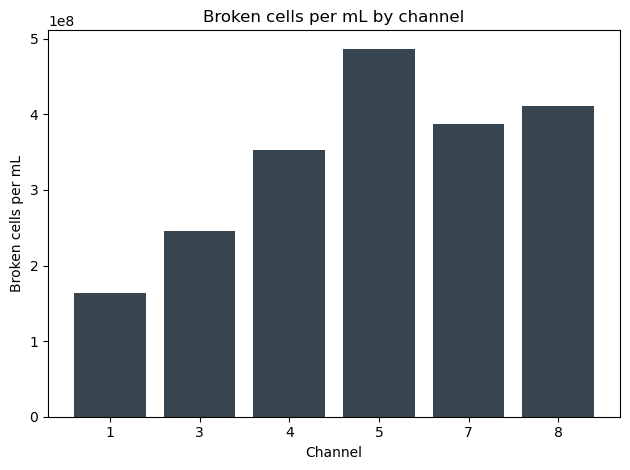

In [14]:
plt.bar(
    data_casy_wide['channel'].astype(str),
    data_casy_wide['broken_cells_per_ml'],
    color='#36454F'
    
)
plt.xlabel('Channel')
plt.ylabel('Broken cells per mL')
plt.title('Broken cells per mL by channel')

plt.tight_layout()
plt.show()

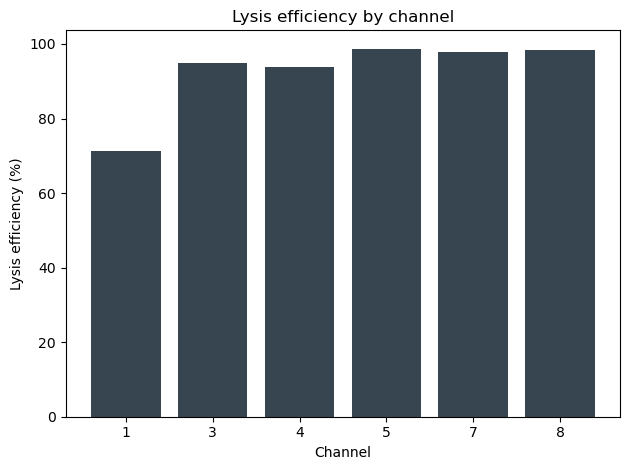

In [15]:
plt.bar(
    data_casy_wide['channel'].astype(str),
    data_casy_wide['lysis_efficiency_pct'],
    color='#36454F'
)
plt.xlabel('Channel')
plt.ylabel('Lysis efficiency (%)')
plt.title('Lysis efficiency by channel')
plt.tight_layout()
plt.show()

In [16]:
### qPCR determination steps
# 96-well plate 
# To each well aded:
# - 15 μL master-mix (primers, polymerase, SYBR-green, mQH2O)
# - 5 μL (diluted) cell extract or standard
#
# qPCR Standard curve:
# 3 independent serial dilutions 
# 7 points, diluting the solution 10 times in each step
# initial [DNA] = 0.04 ng DNA / μL
#
# Steps to make standard curve:
# 1. Calculate [DNA] in each standard dilution -> use dilution_factor column
# 2. Find the concentration in well (15 μL + 5 μL)
# 3. Fit linear regression model to Ct ~ log10([DNA])
# 
# From ng to # of molecules:
# 
# Ignoring the unit conversion for now the formula is:
# dna_molecules_in_well = (dna_conc_standard / dilution_factor) * (sample_volume_in_well / total_volume_in_well) / dna_fragment_molecular_weight * avogadro_number 
#
# where:
#   dna_conc_standard = 0.04 ng/μL.  # initial concentration of DNA in the standard solution
#   dilution_factor = 10 ** standard_point  # dilution factor for each standard point
#   sample_volume_in_well = 5 μL  # volume of diluted DNA solution added to the well
#   total_volume_in_well = 20 μL  # total volume in the well (5 μL diluted DNA + 15 μL master mix)
#   dna_fragment_molecular_weight = sequence_length * average_weight_per_base_pair  # weight of the DNA fragment in ng
#   avogadro_number = 6.022e23  # number of molecules per mole
#   dna_conc_diluted = dna_conc_standard / dilution_factor  # concentration of DNA in the diluted standard solution


In [17]:
# qPCR cycle threshold (Ct) values are inversely proportional to the amount of target nucleic acid in the sample. 
# A lower Ct value indicates a higher amount of target nucleic acid, 
# while a higher Ct value indicates a lower amount of target nucleic acid. 
# This is because it takes fewer cycles for the fluorescence signal to reach 
# the threshold when there is more target nucleic acid present in the sample.

data_qpcr = pd.read_csv(f'{data_dir}/qPCR.csv', index_col=False)
data_qpcr.head()

# order by sample and time
data_qpcr = data_qpcr.sort_values(by=['sample_id'])
data_qpcr.head()

#Ct change per sample

,sample_id,channel,replicate,dilution_replicate,Ct,dilution_factor,sample_class,template_vol,final_vol
0,200206_0_4,4.0,1,1.0,15,10,sample,5,20
18,200206_0_4,4.0,2,1.0,15,10,sample,5,20
30,200206_0_4,4.0,2,3.0,21,1000,sample,5,20
6,200206_0_4,4.0,1,2.0,18,100,sample,5,20
12,200206_0_4,4.0,1,3.0,21,1000,sample,5,20


In [18]:
# standard_point 1..7 = S1..S7
# dilution_factor = 10 * standard_point starting at 10
# 
# S1 dilution_factor = 10^1 = 10
# ...
# S6 dilution_factor = 10^6 = 1000000
# S7 dilution_factor = 10^7 = 10000000
#
# replicate 1..3 = each standard point is measured 3 times

In [19]:
### From ng to # of molecules

# Checked it manully and its 1085
with open(f'{data_dir}/standard_fragment_sequence.txt', 'r') as f:
    fragment_content = f.read().strip()
length_bp = len(fragment_content) # 1085

# REF: Ploidy in Cynabacteria (2011), Griesen et al. 
# under spectrocopic method for ploidy determination
weight_bp = 660 # g/mol per base pair

molecular_weight_g_per_mol = length_bp * weight_bp
print(f'Molecular weight: {molecular_weight_g_per_mol} g/mol')

Molecular weight: 716100 g/mol


In [ ]:
dna_conc_standard_ng_per_ul = 0.04 
sample_volume_in_well_ul = 5
total_volume_in_well_ul = 20
avogadro_number = 6.022e23
weight_bp_g_per_mol = 660  # g/mol per bp for dsDNA
length_bp = 1085  # length of the DNA fragment in base pairs
molecular_weight_g_per_mol = length_bp * weight_bp_g_per_mol

qpcr = data_qpcr.copy()

qpcr_standard = qpcr.loc[qpcr['sample_class'].eq('standard')].copy()

# S1 -> 1, ..., S7 -> 7
qpcr_standard['standard_point'] = (
    qpcr_standard['sample_id'].astype(str).str.extract(r'(\d+)')[0].astype(int)
)

# REF: 
# dna_molecules_in_well = (dna_conc_standard / dilution_factor) * (sample_volume_in_well / total_volume_in_well) / dna_fragment_molecular_weight * avogadro_number 
qpcr_standard['dna_conc_diluted_ng_per_ul'] =  dna_conc_standard_ng_per_ul / qpcr_standard['dilution_factor']


qpcr_standard['dna_conc_in_well_ng_per_ul'] = qpcr_standard['dna_conc_diluted_ng_per_ul'] * (sample_volume_in_well_ul / total_volume_in_well_ul)

# 1e-9  => ng -> g
qpcr_standard['dna_molecules_in_well_per_ul'] = qpcr_standard['dna_conc_in_well_ng_per_ul'] * 1e-9 / molecular_weight_g_per_mol * avogadro_number

qpcr_standard['log10_dna_molecules_in_well_per_ul'] = np.log10(qpcr_standard['dna_molecules_in_well_per_ul'])

qpcr_standard[
    [
        'sample_id', 'standard_point', 'replicate', 'dilution_factor', 'Ct',
        'dna_conc_diluted_ng_per_ul', 'dna_conc_in_well_ng_per_ul',
        'dna_molecules_in_well_per_ul', 'log10_dna_molecules_in_well_per_ul'
    ]
].sort_values(['standard_point', 'replicate'])


,sample_id,standard_point,replicate,dilution_factor,Ct,dna_conc_diluted_ng_per_ul,dna_conc_in_well_ng_per_ul,dna_molecules_in_well_per_ul,log10_dna_molecules_in_well_per_ul
36,S1,1,1,10,9,4.000000e-03,1.000000e-03,9.124242e+08,8.960197
43,S1,1,2,10,9,4.000000e-03,1.000000e-03,9.124242e+08,8.960197
50,S1,1,3,10,9,4.000000e-03,1.000000e-03,9.124242e+08,8.960197
37,S2,2,1,100,12,4.000000e-04,1.000000e-04,9.124242e+07,7.960197
44,S2,2,2,100,12,4.000000e-04,1.000000e-04,9.124242e+07,7.960197
51,S2,2,3,100,12,4.000000e-04,1.000000e-04,9.124242e+07,7.960197
38,S3,3,1,1000,15,4.000000e-05,1.000000e-05,9.124242e+06,6.960197
45,S3,3,2,1000,15,4.000000e-05,1.000000e-05,9.124242e+06,6.960197
52,S3,3,3,1000,15,4.000000e-05,1.000000e-05,9.124242e+06,6.960197
39,S4,4,1,10000,18,4.000000e-06,1.000000e-06,9.124242e+05,5.960197


In [25]:
# save processed data
qpcr_standard.to_csv(f'{data_output_dir}/qpcr_standard_output.csv', index=False)